## **Figure-S18**

In [1]:
import pandas as pd
import polars as pl
from collections import defaultdict
import sys
import numpy as np
import os
import re
import pyopenms as po

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("pyopenms version", po.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
pyopenms version 3.3.0
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
names = dict(silico='in-silico',
             bruker='timsTOF, 2024')

condition = dict(orig='Initial', refined='Reconstructed', tl='Transfer-Learn')

In [4]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def extract_lib_info_alt(dirname: str):
    dilution_match = re.search(r'(\d+pg)', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderOSW(osw_dir, pyprophet_folder = 'pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', alt_lib_dir=False, norm_factor=10000, **kwargs):
    # Dictionary to store results by dilution and replicate
    rslts = {}
    rslts_frag = {}

    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.match(r'100pg', d)]
    
    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            if replicate == '1': #only load the first replicate since this is all that is needed for this plot
                # Look for library directories (ending with _lib)
                if alt_lib_dir:
                    lib_dirs = [d for d in os.listdir(replicate_path) 
                            if os.path.isdir(os.path.join(replicate_path, d))
                            and d.startswith('lib')]
                else:
                    lib_dirs = [d for d in os.listdir(replicate_path) 
                               if os.path.isdir(os.path.join(replicate_path, d))
                               and d.endswith('_lib')]
    
                for lib_dir in lib_dirs:
                    if not '100pg' in lib_dir: # do not show the MBR level (100pg with 100pg) because not everything has this
                        # Path to report.tsv
                        report_path = os.path.join(replicate_path, lib_dir, pyprophet_folder, replicate_dir + ".oswpq/" )
                        
                        if alt_lib_dir:
                            lib_dilution = extract_lib_info_alt(lib_dir)
                        else:
                            lib_dilution = extract_lib_info(lib_dir)
    
                        # Check if file exists, if not use pyprophet fallback
                        if not os.path.exists(report_path):
                            report_path = os.path.join(replicate_path, lib_dir, pyprophet_fallback, replicate_dir + ".oswpq/" )
    
                        rslts[f'Reconstructed (Reference = {lib_dilution})'] = getPrecursorDf_Characteristics_oswpq(report_path)
                        rslts_frag[f'Reconstructed (Reference = {lib_dilution})'] = compute_frag_intensity_residuals_oswpq(report_path, norm_factor=10000)


                        print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
        return (rslts, rslts_frag)

def appendOriginalResultsOSW(osw_dir, rslts, rslts_frag, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', norm_factor=10000, **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.search(r'100pg', d)]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        dilution, replicate = extract_info(dilution_dir)
        if replicate == '1':
            if dilution == '0':
                continue
            report_path = os.path.join(osw_dir, dilution_dir, pyprophet_folder, dilution_dir + ".oswpq")
            
            # Check if file exists, if not use pyprophet fallback
            if not os.path.exists(report_path):
                report_path = os.path.join(osw_dir, dilution_dir, pyprophet_fallback, dilution_dir + ".oswpq/" )
            
            rslts[condition['orig']] = getPrecursorDf_Characteristics_oswpq(report_path)
            rslts_frag[condition['orig']] = compute_frag_intensity_residuals_oswpq(report_path, norm_factor=norm_factor)

            print(f"Processed {dilution_dir} rep {replicate} | lib original")

osw = {}
osw_frag = {}

osw[names['bruker']], osw_frag[names['bruker']] = loadRefinedFolderOSW("../../results/SCP-Bruker-Lib-Refined-Analysis/osw/")
appendOriginalResultsOSW("../../results/SCP-Bruker-Library-Analysis/osw/", osw[names['bruker']], osw_frag[names['bruker']])


# note it is SVM even though it is in the LDA folder
osw[names['silico']], osw_frag[names['silico']] = loadRefinedFolderOSW("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/osw/", pyprophet_folder='pyprophet_SVM', alt_lib_dir=False)
appendOriginalResultsOSW("../../results/SCP-PeptDeep-NoMods-Analysis/osw/", osw[names['silico']], osw_frag[names['silico']], pyprophet_folder='pyprophet_SVM', norm_factor=1)

../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630.oswpq/
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630.oswpq/
Processed 100pg rep 1 | lib dilution 500pg | lib directory HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630/HeLa02DDM_250pg_5x3_PyDIA_1_S1-C7_1_1636_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630.oswpq/
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630/HeLa02DDM_250pg_5x3_PyDIA_1_S1-C7_1_1636_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630.oswpq/
Processed 100pg rep 1 | lib dilution 250pg | lib directory HeLa02DDM_250pg_5x

---

---

In [5]:
tmp = {}
for i in osw.keys():
    tmp[i] = pd.concat(osw[i]).reset_index(names=['Condition', 0]).drop(columns=0)
osw_df = pd.concat(tmp).reset_index(names=['Library', 0]).drop(columns=0)

In [6]:
tmp = {}
for i in osw_frag.keys():
    tmp[i] = pd.concat(osw_frag[i]).reset_index(names=['Condition', 0]).drop(columns=0)
osw_frag_df = pd.concat(tmp).reset_index(names=['Library', 0]).drop(columns=0)

---

In [7]:
def create_characteristics_boxplot(ax, data, y, ylabel, show_xticks, ylim=None, font_size_small=7, font_size_medium=10, font_size_large=11):
    sns.set_palette(["tab:blue", '#FFC499', "#FFAA62", "tab:orange", "#CC6500", '#A35000'])
    sns.boxplot(data=data,
                x='Library', 
                hue='Condition', 
                y=y, showfliers=False, ax=ax, order=names.values(), legend=False, hue_order=[condition['orig']] + [condition['refined'] + f' (Reference = {x}pg)' for x in ['250', '500', '1000', '2500', '5000'] ])
    ax.set_ylabel(ylabel, fontsize=font_size_medium)
    ax.axhline(0, color='black')

    if not show_xticks:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Library", fontsize=font_size_medium)
        for l in ax.get_xticklabels():
            if l.get_text() == 'in-silico':
                l.set_fontstyle('italic')
        
    
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    if ylim is not None:
        ax.set_ylim(ylim)


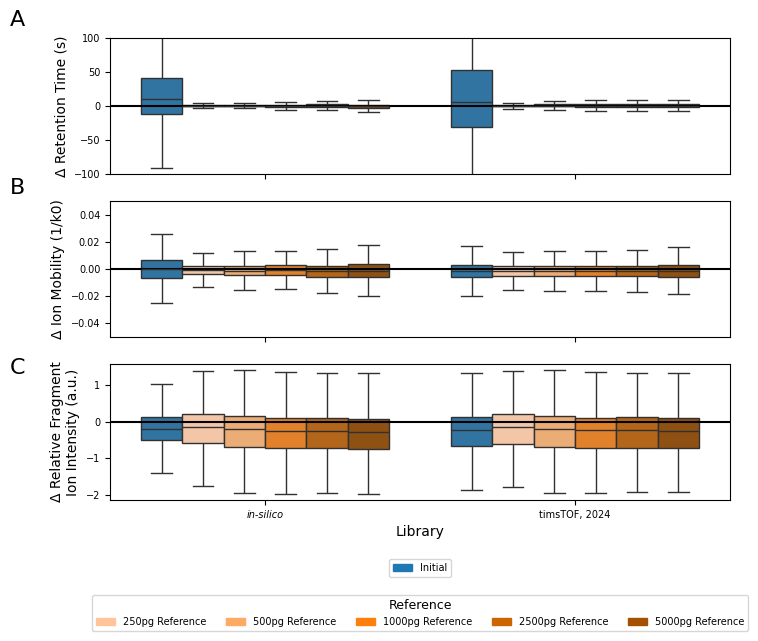

In [10]:
fig, (ax1,ax2,ax3) = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

create_characteristics_boxplot(ax1, osw_df, 'FEATURE.DELTA_RT', 'Δ Retention Time (s)', show_xticks=False, ylim=(-100, 100))

create_characteristics_boxplot(ax2, osw_df, 'FEATURE_MS2.DELTA_IM', 'Δ Ion Mobility (1/k0)', show_xticks=False, ylim=(-0.05, 0.05))

create_characteristics_boxplot(ax3, osw_frag_df, 'residual', 'Δ Relative Fragment\nIon Intensity (a.u.)', show_xticks=True)


orange_colors = ['#FFC499', '#FFAA62', '#FF7F0E', '#CC6500', '#A35000']
reference_levels = ['250pg Reference', '500pg Reference', '1000pg Reference', '2500pg Reference', '5000pg Reference']


initial_patch = mpatches.Patch(color='tab:blue', label='Initial')

reconstructed_patches = [
    mpatches.Patch(color=orange_colors[i], label=reference_levels[i]) 
    for i in range(5)
]

legend1 = ax3.legend(
    handles=[initial_patch],
    loc='lower center',
    fontsize=7,
    bbox_to_anchor=(0.5, -0.6), # Moves the legend outside and below the plot
)

# --- 2. Create the Second Legend (Reconstructed) ---
legend2 = ax3.legend(
    handles=reconstructed_patches,  # NOW USES THE LIST OF 5 PATCHES
    title='Reference',
    loc='lower center',
    bbox_to_anchor=(0.5, -1), # Positions it below the first legend
    fontsize=7,
    title_fontsize=9,
    ncol=5, # UPDATED: Set to 5 to show all patches horizontally
)

# You must manually add the first legend back to the axis when using multiple legends
ax3.add_artist(legend1)

fig.text(0, 0.9, 'A', fontsize=16) 
fig.text(0, 0.62, 'B', fontsize=16)
fig.text(0, 0.32, 'C', fontsize=16) 

plt.savefig("Figure-S18.png", dpi=300, bbox_inches='tight')
